# Projeto Prático: Machine Learning & Inteligência de Mercado
## Análise Estratégica da Concentração no Comércio Global de Bens Criativos (Dataset OpenFCS)

---

> **Componente Curricular:** Machine Learning aplicado à Administração
> **Instituição:** Curso de Graduação em Administração
> **Objetivo:** Aplicação prática de Ciência de Dados, Machine Learning e Inteligência Artificial Generativa para diagnosticar padrões de concentração e (re)configuração competitiva no comércio mundial de bens criativos, a partir do acervo aberto OpenFCS (UNCTAD, alinhado ao UNESCO Framework for Cultural Statistics 2025).

---

### Corpo Docente & Contato

| Atributo | Detalhes |
| :--- | :--- |
| **Professor** | **Sérgio Assunção Monteiro, D.Sc.** |
| **Conecte-se no LinkedIn** | [🌐 linkedin.com/in/sergio-assunção-monteiro](https://www.linkedin.com/in/sergio-assun%C3%A7%C3%A3o-monteiro-b781897b/) |
| **Currículo Lattes** | [🔬 lattes.cnpq.br/9489191035734025](http://lattes.cnpq.br/9489191035734025) |
| **Repositório GitHub** | [💻 github.com/sergiomonteiro76](https://github.com/sergiomonteiro76) |

---

### Sobre este Notebook
Este ambiente foi configurado para que os alunos atuem como **Analistas de Inteligência de Mercado**. Ao longo do semestre, com apoio de modelos de linguagem (IA) integrados ao ecossistema do Google Colab, vamos reconstruir — do dado bruto ao modelo preditivo — o diagnóstico de estrutura competitiva de um setor econômico real: o comércio internacional de bens criativos.

* **Fonte de dados:** [OpenFCS Dataset](https://doi.org/10.5281/zenodo.21211053) — Monteiro & Dubeux (2026), CC-BY-4.0.
* **Material de apoio:** Capítulos 1 a 3 das notas de aula (Ambiente e primeiro contato; Python/pandas/NumPy; Bases de Dados e SQL).

## Aula 5 — Estatística Descritiva e Probabilidade Aplicada
Depois de auditar a qualidade dos dados na Aula 4, chegou a hora de descrevê-los com rigor estatístico: medidas de tendência central, dispersão, posição, e as primeiras visualizações que vão sustentar todo o raciocínio de concentração de mercado do restante do curso.

# **Recarregar o acervo**

In [1]:
import requests, zipfile, io, os
import pandas as pd
import numpy as np

url = (
    "https://zenodo.org/records/21211053/files/"
    "openfcs_v1.0.0.zip?download=1"
)
resp = requests.get(url)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    z.extractall("openfcs")

endereco = "openfcs/openfcs-1.0.0/data/derived/"
edges = pd.read_csv(endereco + "trade_edges.csv")
edges7 = edges[edges["resolution"] == "cer7"].copy()

print(f"edges7: {len(edges7):,} linhas")   # deve dar 1.026.400

edges7: 1,026,400 linhas


### 5.1 Medidas de tendência central e dispersão
Três formas de responder "qual é o valor típico de um fluxo de exportação?" — e por que elas discordam tanto.

In [2]:
valores = edges7["value_usd_millions"]

media = valores.mean()
mediana = valores.median()
moda = valores.mode()[0]
desvio_padrao = valores.std()
variancia = valores.var()
amplitude = valores.max() - valores.min()

print(f"Media:          {media:,.4f}")
print(f"Mediana:        {mediana:,.4f}")
print(f"Moda:           {moda:,.4f}")
print(f"Desvio padrao:  {desvio_padrao:,.4f}")
print(f"Variancia:      {variancia:,.4f}")
print(f"Amplitude:      {amplitude:,.2f}")

Media:          18.4855
Mediana:        0.0310
Moda:           0.0000
Desvio padrao:  398.0903
Variancia:      158,475.8692
Amplitude:      82,696.26


Repare: a média é muito maior que a mediana. Isso já é um sintoma — vamos confirmar visualmente daqui a pouco.

### 5.2 Medidas de posição: quartis e percentis

In [3]:
print(valores.describe())
print()
print("Percentil 90:", valores.quantile(0.90))
print("Percentil 99:", valores.quantile(0.99))
print("Percentil 99.9:", valores.quantile(0.999))

count    1.026400e+06
mean     1.848550e+01
std      3.980903e+02
min      0.000000e+00
25%      2.000000e-03
50%      3.100000e-02
75%      5.040000e-01
max      8.269626e+04
Name: value_usd_millions, dtype: float64

Percentil 90: 5.79
Percentil 99: 260.659070000001
Percentil 99.9: 2891.1247910001675


### 5.3 Visualizando a distribuição: histograma

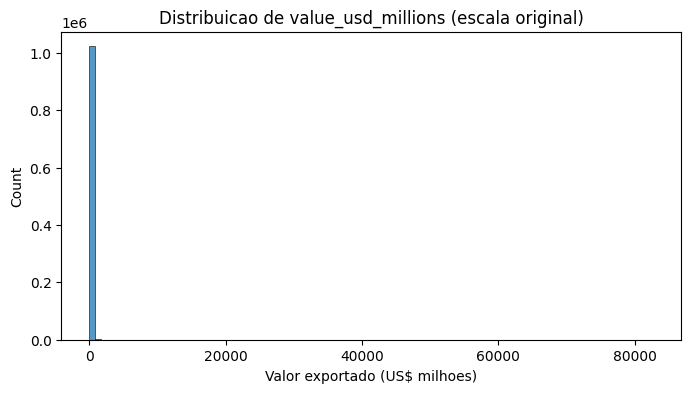

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(valores, bins=100, ax=ax)
ax.set_title("Distribuicao de value_usd_millions (escala original)")
ax.set_xlabel("Valor exportado (US$ milhoes)")
plt.show()

O histograma confirma o que a Aula 4 já havia sinalizado com o IQR: a distribuição é extremamente assimétrica à direita (*right-skewed*) — poucos fluxos gigantescos esmagam a escala visual dos milhões de fluxos pequenos. É por isso que a média (puxada pelos valores extremos) fica tão acima da mediana.

**Transformação logarítmica** é a resposta padrão para esse tipo de distribuição:

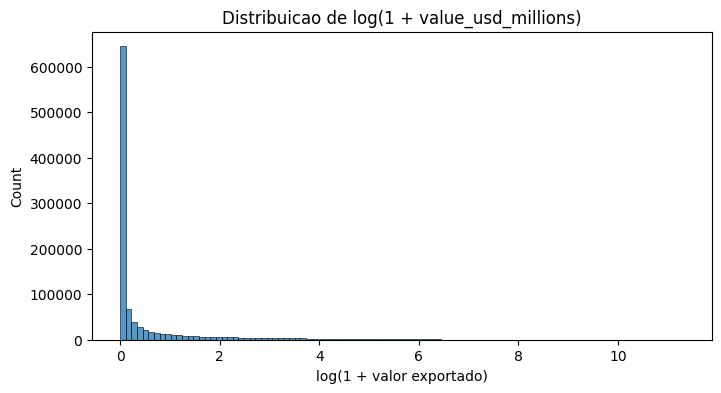

In [5]:
edges7["log_valor"] = np.log1p(edges7["value_usd_millions"])

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(edges7["log_valor"], bins=100, ax=ax)
ax.set_title("Distribuicao de log(1 + value_usd_millions)")
ax.set_xlabel("log(1 + valor exportado)")
plt.show()

### 5.4 Comparando domínios: boxplot

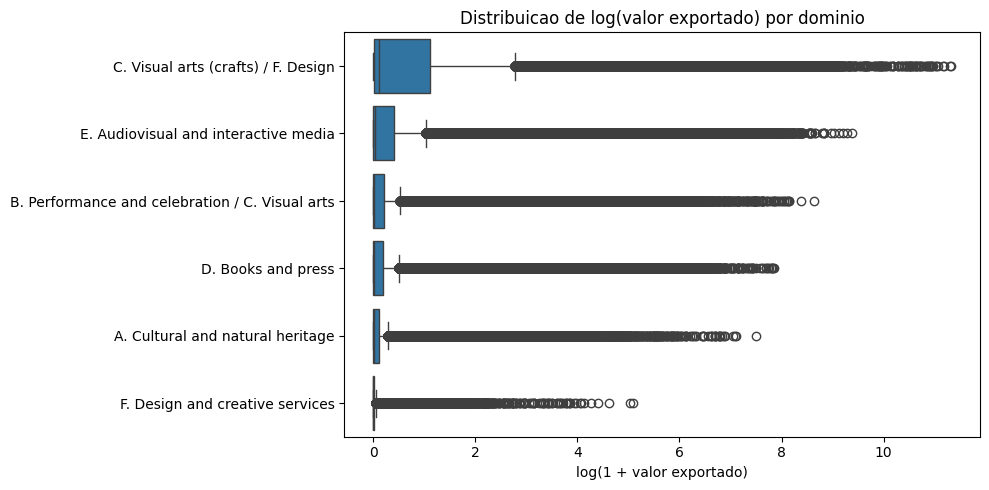

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ordem = edges7.groupby("fcs_domain")["log_valor"].median().sort_values(ascending=False).index
sns.boxplot(data=edges7, x="log_valor", y="fcs_domain", order=ordem, ax=ax)
ax.set_title("Distribuicao de log(valor exportado) por dominio")
ax.set_xlabel("log(1 + valor exportado)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 5.5 Reconhecendo distribuições: assimetria (skewness)
Média e mediana quase iguais sugerem uma distribuição simétrica (perto da Normal). Média bem maior que a mediana é a assinatura de uma distribuição assimétrica à direita — comum em preços, salários, e, como vimos, comércio internacional.

In [7]:
from scipy import stats

skew_original = stats.skew(edges7["value_usd_millions"])
skew_log = stats.skew(edges7["log_valor"])

print(f"Assimetria (escala original): {skew_original:.2f}")
print(f"Assimetria (escala log):      {skew_log:.2f}")
print("\nReferencia: 0 = simetrica | >0 = cauda a direita | <0 = cauda a esquerda")

Assimetria (escala original): 99.43
Assimetria (escala log):      3.07

Referencia: 0 = simetrica | >0 = cauda a direita | <0 = cauda a esquerda


### 5.6 Um mini-dashboard exploratório
Reunindo tudo em um único painel — o mesmo espírito do painel executivo da Aula 15, em miniatura.

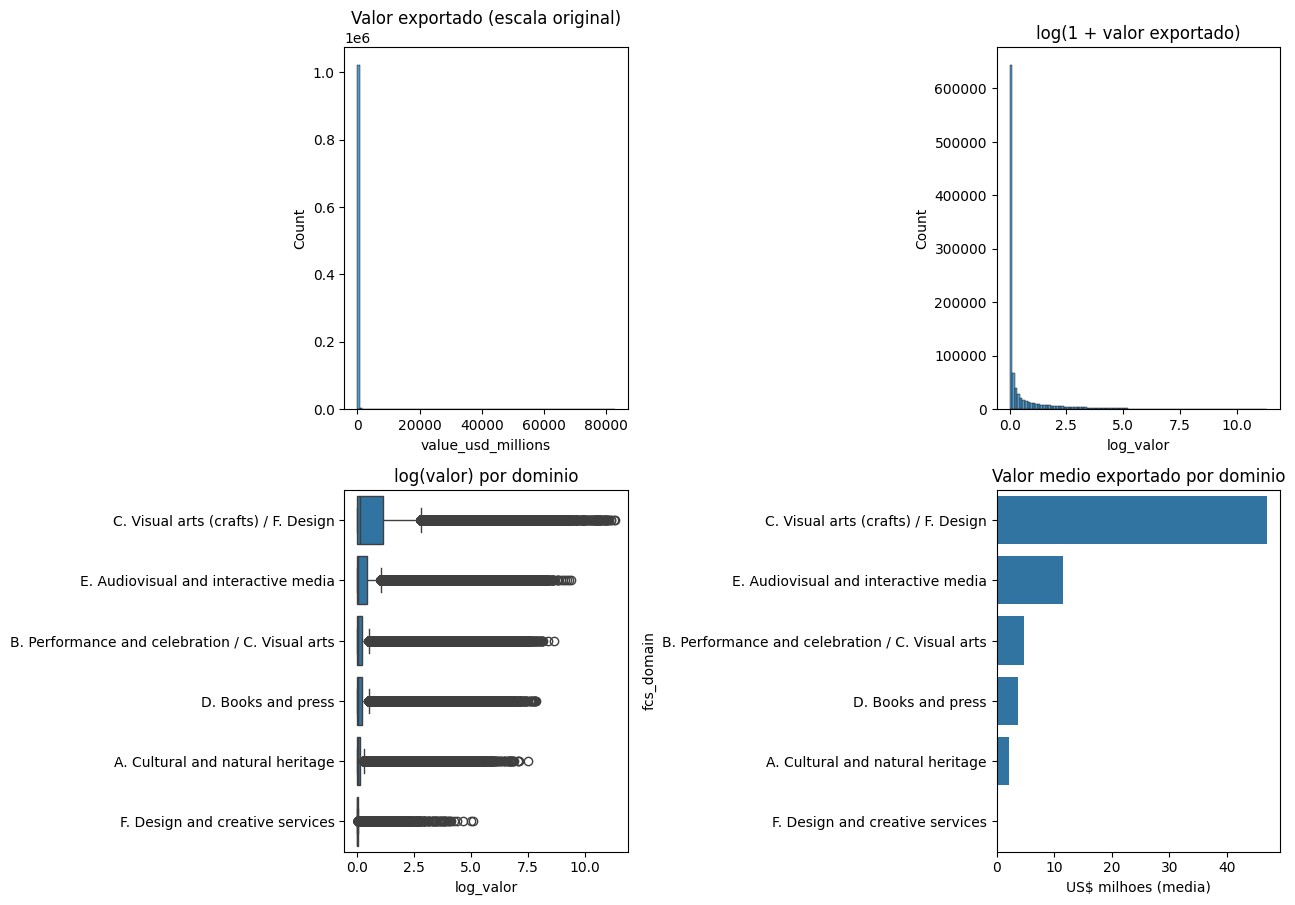

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(edges7["value_usd_millions"], bins=100, ax=axes[0, 0])
axes[0, 0].set_title("Valor exportado (escala original)")

sns.histplot(edges7["log_valor"], bins=100, ax=axes[0, 1])
axes[0, 1].set_title("log(1 + valor exportado)")

sns.boxplot(data=edges7, x="log_valor", y="fcs_domain", order=ordem, ax=axes[1, 0])
axes[1, 0].set_title("log(valor) por dominio")
axes[1, 0].set_ylabel("")

media_por_dominio = (
    edges7.groupby("fcs_domain")["value_usd_millions"]
    .mean()
    .sort_values(ascending=False)
)
sns.barplot(x=media_por_dominio.values, y=media_por_dominio.index, ax=axes[1, 1])
axes[1, 1].set_title("Valor medio exportado por dominio")
axes[1, 1].set_xlabel("US$ milhoes (media)")

plt.tight_layout()
plt.show()

## 🧪 Exercícios Práticos — Aula 5

> **Como usar:** resolva cada exercício em uma célula de código abaixo do enunciado. Depois, leve o resultado para uma IA usando o *prompt sugerido*.

---

### Exercício 1 — Média vs. mediana, domínio a domínio
**📝 Tarefa:** Para cada domínio, calcule a média e a mediana de `value_usd_millions`. Em quais domínios a diferença entre as duas é maior? O que isso sugere sobre a presença de fluxos extremos nesse domínio?

**🤖 Pergunte à IA:**
> "Nestes domínios, a média é [X] vezes maior que a mediana: [cole os números]. O que essa razão entre média e mediana costuma indicar sobre a forma de uma distribuição?"

---

### Exercício 2 — Percentis como referência de negócio
**📝 Tarefa:** Calcule o percentil 95 de `value_usd_millions` para um domínio à sua escolha. Quantos fluxos desse domínio estão acima desse percentil? O que caracteriza esses fluxos (países, anos)?

**🤖 Pergunte à IA:**
> "Os fluxos acima do percentil 95 em [domínio] envolvem principalmente estes países: [cole a lista]. Isso é esperado dado o que sabemos sobre esse mercado, ou é surpreendente?"

---

### Exercício 3 — Assimetria por domínio
**📝 Tarefa:** Calcule a assimetria (`stats.skew`) de `value_usd_millions` para cada domínio separadamente. Qual domínio é o mais assimétrico? Qual é o menos?

**🤖 Pergunte à IA:**
> "A assimetria de [domínio A] é [valor] e a de [domínio B] é [valor]. Em termos de concentração de mercado, o que uma assimetria muito mais alta pode sugerir sobre [domínio A] em comparação a [domínio B]?"

---

### Exercício 4 — Construindo um histograma comparativo
**📝 Tarefa:** Usando `sns.histplot` com o parâmetro `hue="fcs_domain"` (ou gráficos separados), compare a distribuição de `log_valor` entre dois domínios contrastantes (um do topo e um da base do boxplot da Célula 12).

**🤖 Pergunte à IA:**
> "Comparei a distribuição de valor exportado (em log) entre dois domínios. [Descreva o que você viu]. Duas distribuições com médias parecidas mas formas diferentes contam a mesma história de mercado? Por quê?"

---

### Exercício 5 — Qual medida de dispersão usar?
**📝 Tarefa:** Calcule o desvio padrão e o IQR (visto na Aula 4) de `value_usd_millions`. Para uma distribuição tão assimétrica quanto esta, qual das duas medidas de dispersão você recomendaria para um relatório executivo? Justifique.

**🤖 Pergunte à IA:**
> "Tenho uma variável com desvio padrão de [X] e IQR de [Y], em uma distribuição fortemente assimétrica. Por que o desvio padrão pode ser enganoso nesse caso, e o IQR mais confiável?"